# Shipment Weight Estimation — EDA & Model Comparison

Synthetic data (no real warehouse data received yet). This notebook covers:
1. Null/quality checks
2. Distributions & correlations
3. Outliers
4. Model comparison: linear -> ridge -> random forest -> gradient boosted trees
5. Evaluation: MAE/RMSE, bias by carton type & item count, largest errors
6. SHAP feature importance

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from shipment_weight.data_gen import generate_shipments
from shipment_weight.features import add_derived_features, ALL_FEATURES, NUMERIC_FEATURES, CATEGORICAL_FEATURES, TARGET
from shipment_weight.train import make_pipeline, MODEL_CANDIDATES, split_data, train_all_candidates
from shipment_weight.evaluate import regression_metrics, compare_to_baseline, bias_by_segment, bias_by_item_count_bucket, largest_errors

sns.set_theme(style='whitegrid')
df = generate_shipments(n_shipments=8000, seed=42)
df.shape

(8000, 11)

We generate 8,000 synthetic shipments rather than load a CSV because no real
Medusa warehouse data exists yet (see `MODEL_CARD.md`). The generator
(`shipment_weight/data_gen.py`) deliberately injects the kind of gap this
whole project is about: a `theoretical_weight_oz` computed from catalog data,
and an `actual_weight_oz` that's noisier and biased in ways a model could
learn to correct for. Every assumption behind that noise is documented in
`docs/data_assumptions.md` — treat results in this notebook as "does the
pipeline work," not "is the model accurate," until real data replaces this.

## 1. Null / quality checks

`df.info()` shows dtypes and non-null counts per column in one shot;
`df.isna().sum()` is the precise per-column count. We check both because
`.info()` is faster to eyeball but `.isna().sum()` is what you'd actually act
on — e.g. deciding whether a column needs an imputer. On synthetic data we
expect zero true NaNs (the generator always fills every column), so this
check mostly exists as a habit to carry over to real data, where missing
values are the norm rather than the exception. Missing catalog weights are
intentionally *not* surfaced as NaN — see the next cell.

In [2]:
df.info()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   theoretical_weight_oz         8000 non-null   float64
 1   actual_weight_oz              8000 non-null   float64
 2   carton_type                   8000 non-null   str    
 3   item_count                    8000 non-null   int64  
 4   total_item_volume_in3         8000 non-null   float64
 5   item_categories               8000 non-null   str    
 6   category_mode                 8000 non-null   str    
 7   ship_method                   8000 non-null   str    
 8   packing_material              8000 non-null   str    
 9   num_missing_catalog_weights   8000 non-null   int64  
 10  category_avg_weight_error_oz  8000 non-null   float64
dtypes: float64(4), int64(2), str(5)
memory usage: 687.6 KB


theoretical_weight_oz           0
actual_weight_oz                0
carton_type                     0
item_count                      0
total_item_volume_in3           0
item_categories                 0
category_mode                   0
ship_method                     0
packing_material                0
num_missing_catalog_weights     0
category_avg_weight_error_oz    0
dtype: int64

In [3]:
# Items with missing catalog weights are flagged via num_missing_catalog_weights
# rather than left as NaN in theoretical_weight_oz -- the warehouse simply never
# logged a weight for that line, so theoretical excludes it.
df['num_missing_catalog_weights'].value_counts().sort_index()

num_missing_catalog_weights
0    6722
1    1179
2      95
3       4
Name: count, dtype: int64

Most shipments (6,722/8,000) have 0 missing catalog weights, but a long tail
has 1-3. This is a 5% per-item-line missing rate compounding across shipments
with multiple lines — exactly what `CATALOG_MISSING_RATE` in `data_gen.py`
specifies. The model sees this as a numeric feature
(`num_missing_catalog_weights`) rather than a NaN, which matters: a NaN in
`theoretical_weight_oz` would force an imputation decision per-row, while
counting *how many* lines were missing lets the model learn "more missing
weights -> theoretical_weight_oz is more likely to undercount -> lean toward
predicting higher."

## 2. Distributions

We look at distributions before modeling because the *shape* of a variable
tells you what kind of model and what kind of error metric make sense.
Weight is physically bounded below by zero and tends to be right-skewed
(many light shipments, a few heavy ones) — if that skew is severe, a model
trained on raw oz might underfit the heavy tail, and a log-transform or a
metric less sensitive to scale (like MAPE) might be worth considering. The
"actual - theoretical" panel is the most important one here: its shape *is*
the thing the model is trying to predict.

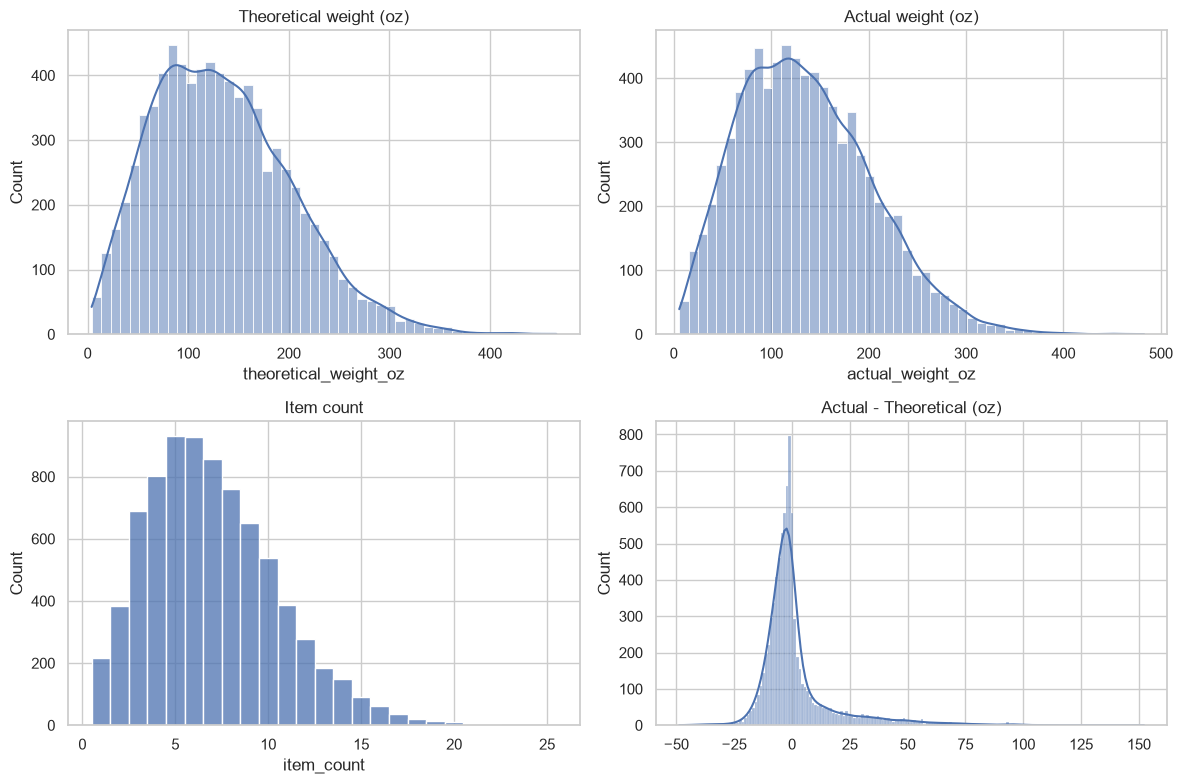

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df['theoretical_weight_oz'], ax=axes[0,0], kde=True).set_title('Theoretical weight (oz)')
sns.histplot(df['actual_weight_oz'], ax=axes[0,1], kde=True).set_title('Actual weight (oz)')
sns.histplot(df['item_count'], ax=axes[1,0], discrete=True).set_title('Item count')
sns.histplot(df['actual_weight_oz'] - df['theoretical_weight_oz'], ax=axes[1,1], kde=True).set_title('Actual - Theoretical (oz)')
plt.tight_layout()

The "actual - theoretical" histogram should look roughly bell-shaped and
centered slightly negative (the synthetic baseline tends to overestimate —
see the bias column in section 6) with a few long tails in both directions.
Those tails are the 2% mispack outliers injected by the generator: most
shipments have a small, explainable gap, but a handful have a missed item,
extra item, or wrong-carton mistake that swings the error by tens of ounces.
A model can learn the bulk of the bell curve; it has no signal to anticipate
the tails, which is why they show up again in the "largest errors" table
later.

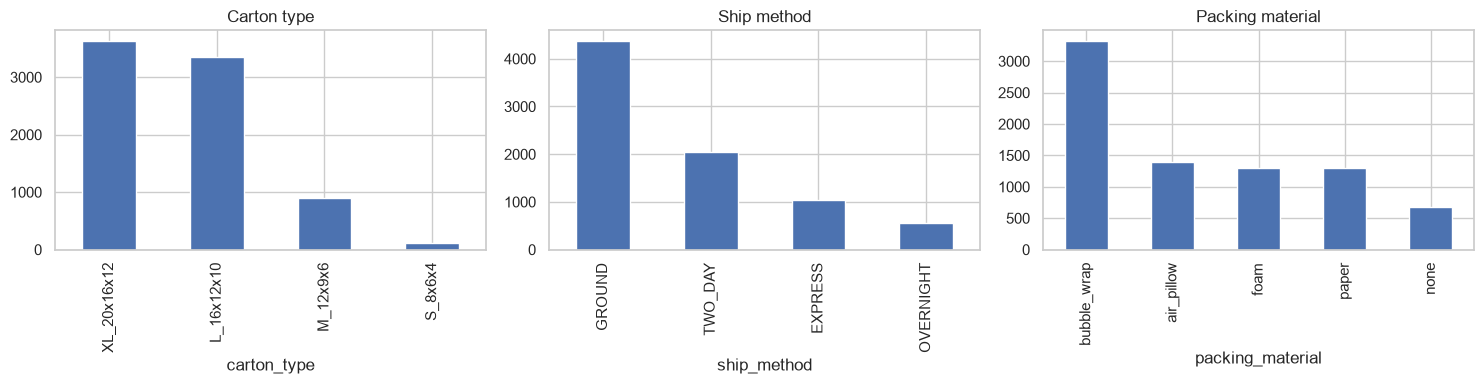

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['carton_type'].value_counts().plot(kind='bar', ax=axes[0], title='Carton type')
df['ship_method'].value_counts().plot(kind='bar', ax=axes[1], title='Ship method')
df['packing_material'].value_counts().plot(kind='bar', ax=axes[2], title='Packing material')
plt.tight_layout()

Categorical features are rarely balanced — `ship_method` here is ~55%
`GROUND` by design (`SHIP_METHOD_PROBS` in `data_gen.py`), and real carrier
mixes are similarly skewed. This matters for two reasons: (1) the model will
naturally be more confident about common categories than rare ones, simply
because it sees more examples, and (2) it previews why the preprocessing
pipeline uses `OneHotEncoder(handle_unknown="ignore")` — a category that's
rare in training is still *known*, but a category that's *never* seen in
training (e.g. a brand-new ship method) needs to degrade gracefully instead
of crashing the pipeline.

## 3. Correlations

Correlation tells you which numeric features move together with the target
*linearly* — it's a cheap first signal, not the final word (it'll miss
nonlinear or interaction effects, which is what SHAP in section 7 is for
instead). The main thing to check here: is any one feature so strongly
correlated with `actual_weight_oz` that it's basically a restatement of the
target (which would be a red flag for leakage), and are any two *features*
highly correlated with each other (multicollinearity), which doesn't break
tree models but can make linear/ridge coefficients hard to interpret.

Text(0.5, 1.0, 'Feature correlation with actual_weight_oz')

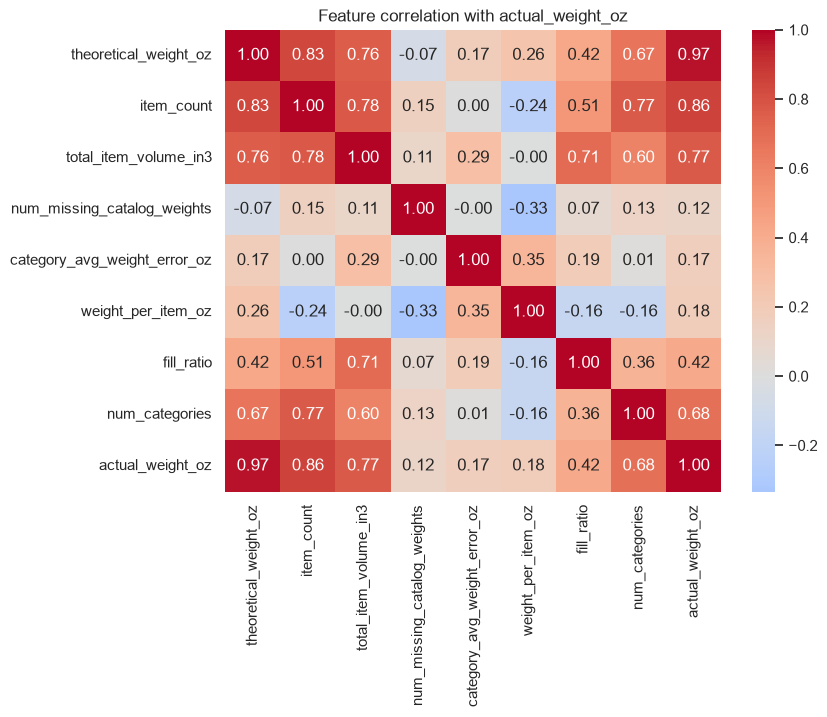

In [6]:
df_feat = add_derived_features(df)
corr = df_feat[NUMERIC_FEATURES + [TARGET]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature correlation with actual_weight_oz')

Expect `theoretical_weight_oz` to dominate the correlation with the target —
that's by construction, since `actual_weight_oz` is theoretical weight plus
noise. That's not leakage (theoretical weight is a real, known-at-prediction-
time input), but it does mean the *interesting* features are the ones that
explain the *residual*: `num_missing_catalog_weights`,
`category_avg_weight_error_oz`, `fill_ratio`. If those show near-zero
correlation here, it doesn't necessarily mean they're useless — it may mean
their relationship with the residual is nonlinear, which SHAP will reveal
later.

## 4. Outliers

Large gaps between theoretical and actual weight, mostly driven by the 2% mispack rate baked into the synthetic generator.

In [7]:
df_feat['abs_error_oz'] = (df_feat['actual_weight_oz'] - df_feat['theoretical_weight_oz']).abs()
df_feat.sort_values('abs_error_oz', ascending=False).head(15)[
    ['theoretical_weight_oz', 'actual_weight_oz', 'abs_error_oz', 'item_count', 'carton_type', 'packing_material']
]

,theoretical_weight_oz,actual_weight_oz,abs_error_oz,item_count,carton_type,packing_material
7625,101.16,253.37,152.21,13,XL_20x16x12,bubble_wrap
5740,97.36,231.86,134.50,13,L_16x12x10,foam
1715,109.23,235.00,125.77,7,XL_20x16x12,air_pillow
3507,59.11,184.37,125.26,9,L_16x12x10,bubble_wrap
6342,63.71,172.19,108.48,9,L_16x12x10,bubble_wrap
1661,84.43,191.18,106.75,5,XL_20x16x12,bubble_wrap
5415,120.15,225.64,105.49,10,XL_20x16x12,air_pillow
7221,78.56,181.48,102.92,7,L_16x12x10,bubble_wrap
4751,65.06,166.21,101.15,9,XL_20x16x12,bubble_wrap
1407,98.49,199.35,100.86,7,XL_20x16x12,bubble_wrap


These are the 15 shipments with the largest theoretical-vs-actual gap (100+
oz on items weighing tens of oz total) — clustered in large/XL cartons with
high item counts, which lines up with where `MISPACK_OUTLIER_RATE` and the
`sqrt(item_count)` compounding noise are concentrated in the generator. The
takeaway isn't "the model is wrong about these" — it's that *no current
feature* signals an upcoming mispack, so these rows are close to irreducible
error for any model trained on this feature set. This is exactly the
"Mispack outliers" failure mode documented in `MODEL_CARD.md`.

## 5. Model comparison: linear -> ridge -> random forest -> gradient boosted trees

We compare four models, increasing in complexity, instead of jumping straight
to the most powerful one:

- **Linear Regression** — the simplest possible baseline; if a fancier model
  can't beat this, the extra complexity isn't earning its keep.
- **Ridge** — linear regression with L2 regularization, which shrinks
  coefficients on correlated features (relevant here given `fill_ratio` and
  `total_item_volume_in3` are related). Tests whether overfitting was an
  issue for plain linear regression.
- **Random Forest** — an ensemble of decision trees; can capture nonlinear
  relationships and feature interactions that linear models can't.
- **Gradient Boosted Trees (GBT)** — trees built sequentially, each
  correcting the previous one's errors; usually the strongest tabular-data
  baseline, at the cost of being slower to train and harder to interpret
  directly (hence the SHAP analysis in section 7).

`split_data` does a random 80/20 train/test split — fine for this synthetic
dataset since rows are i.i.d. by construction, but real shipment data should
likely use a time-based split instead (train on older shipments, test on
newer ones) since that's closer to how the model will actually be used in
production.

In [8]:
X_train, X_test, y_train, y_test = split_data(df, seed=42)
fitted_models = train_all_candidates(X_train, y_train)

results = []
for name, pipe in fitted_models.items():
    preds = pipe.predict(X_test)
    results.append({'model': name, **regression_metrics(y_test, preds)})
pd.DataFrame(results).sort_values('mae_oz')

,model,mae_oz,rmse_oz,bias_oz,within_2oz_pct
3,gradient_boosted_trees,6.299219,10.715039,-0.124770,35.0625
0,linear_regression,6.311372,10.738868,-0.179074,37.0000
1,ridge,6.315546,10.739261,-0.177697,37.1250
2,random_forest,6.594797,11.565193,-0.231126,37.0625


All four models land within ~0.3oz MAE of each other, with GBT edging out
the rest. That near-tie is itself informative: it means the synthetic noise
(per-item normal draws + `sqrt(item_count)`-scaled additive noise) is mostly
*linear/additive*, which is exactly the kind of structure linear models are
good at. It would be a mistake to read this as "tree models don't help for
shipment weight" — it's more accurate to say "this particular synthetic
generator doesn't create the nonlinear interactions (e.g. fragile item +
high item count + undersized carton) where GBT/Random Forest would pull
ahead." Real data, with messier interaction effects, may show a larger gap
between linear and tree-based models. We pick GBT as the production
candidate anyway because it has the best MAE here and the most room to
exploit nonlinear signal if/when real data has more of it.

## 6. Evaluation of best model vs. theoretical-weight baseline

A model is only useful if it beats what's already in use — here, the
theoretical-weight baseline (catalog weights + tare + expected packing
material, with zero learning involved). `compare_to_baseline` runs the same
`regression_metrics` function on both the model's predictions and the raw
theoretical weight, so the comparison is apples-to-apples. The metric to
watch most closely is `bias_oz`: the baseline being systematically biased
(not just noisy) is the actual business problem — a model with the same MAE
but bias near zero is still a meaningful improvement, because consistent
over/under-billing is worse than random noise.

In [9]:
best_name = 'gradient_boosted_trees'
best_model = fitted_models[best_name]
preds = best_model.predict(X_test)
compare_to_baseline(y_test, preds, X_test['theoretical_weight_oz'])

,source,mae_oz,rmse_oz,bias_oz,within_2oz_pct
0,theoretical_weight_baseline,10.046031,18.099605,-2.193631,23.6875
1,model,6.299219,10.715039,-0.124770,35.0625


The model cuts MAE from ~10.0oz to ~6.3oz (~37% reduction) and bias from
-2.2oz to essentially zero. The bias drop matters more than the MAE drop in
practice: the baseline isn't just noisy, it's systematically wrong in one
direction (mispack outliers and packing-material variance both push actual
weight up, and the baseline doesn't account for that), and the model learns
to correct for that systematic skew. Remember this is measuring how well the
model recovers patterns the *generator itself* injected — a real improvement
number can only come from real warehouse feedback data.

In [10]:
print('Bias by carton type')
display(bias_by_segment(y_test, preds, X_test['carton_type'], 'carton_type'))
print('Bias by item count bucket')
display(bias_by_item_count_bucket(y_test, preds, X_test['item_count']))

Bias by carton type


,carton_type,count,mean_bias_oz,mae_oz,std_oz
3,XL_20x16x12,741,-0.217401,8.100650,12.543348
0,L_16x12x10,659,-0.219771,5.308787,9.633771
1,M_12x9x6,179,0.469739,3.048461,5.816475
2,S_8x6x4,21,1.057507,1.523956,1.588778


Bias by item count bucket


,item_count_bucket,count,mean_bias_oz,mae_oz,std_oz
2,6-9,655,0.142468,7.172913,12.113957
1,3-5,477,-0.564643,4.882298,8.405491
3,10+,349,-0.526210,7.706025,12.088681
0,1-2,119,1.344816,3.043981,4.838961


A single overall MAE can hide a model that's great for most shipments and bad
for an important subset — segment-level bias is how you catch that.
`XL_20x16x12` and high item-count buckets carry the most error here, which
isn't a coincidence: those are exactly where the generator concentrates its
compounding noise and mispack outliers (see `docs/data_assumptions.md`). If
this were real data, this table is where you'd decide whether the model is
"good enough to ship" for every segment, or whether a specific segment (e.g.
large multi-item shipments) needs a separate model, more training data, or a
wider confidence interval rather than a single global one.

In [11]:
largest_errors(X_test, y_test, preds, n=15)

,theoretical_weight_oz,item_count,total_item_volume_in3,num_missing_catalog_weights,category_avg_weight_error_oz,weight_per_item_oz,fill_ratio,num_categories,carton_type,ship_method,packing_material,category_mode,actual_weight_oz,predicted_weight_oz,error_oz,abs_error_oz
3856,49.16,5,908.33,1,0.411,9.832000,0.473089,2,L_16x12x10,GROUND,none,grocery,142.87,76.224588,-66.645412,66.645412
1407,98.49,7,1953.57,1,1.545,14.070000,0.508742,3,XL_20x16x12,GROUND,bubble_wrap,electronics,199.35,135.041518,-64.308482,64.308482
7416,172.03,7,1853.99,1,0.407,24.575714,0.482810,3,XL_20x16x12,GROUND,paper,grocery,261.99,199.439502,-62.550498,62.550498
1129,168.53,13,1839.86,1,-0.049,12.963846,0.479130,5,XL_20x16x12,GROUND,foam,apparel,253.10,195.674713,-57.425287,57.425287
7221,78.56,7,1027.25,2,1.263,11.222857,0.535026,2,L_16x12x10,GROUND,bubble_wrap,electronics,181.48,124.362333,-57.117667,57.117667
5223,105.87,7,673.21,1,0.769,15.124286,0.350630,3,L_16x12x10,EXPRESS,bubble_wrap,books,197.34,140.362601,-56.977399,56.977399
7898,189.74,9,2182.10,0,0.196,21.082222,0.568255,4,XL_20x16x12,TWO_DAY,bubble_wrap,apparel,235.61,181.473822,-54.136178,54.136178
4248,169.20,6,1789.55,0,0.811,28.200000,0.466029,3,XL_20x16x12,TWO_DAY,bubble_wrap,home_goods,216.66,162.683184,-53.976816,53.976816
1575,86.23,6,1249.51,1,0.619,14.371667,0.650786,3,L_16x12x10,EXPRESS,paper,grocery,167.30,113.828881,-53.471119,53.471119
5740,97.36,13,1493.22,3,0.140,7.489231,0.777719,4,L_16x12x10,GROUND,foam,electronics,231.86,178.995624,-52.864376,52.864376


All 15 of the model's worst predictions under-predict by 40-65oz, on
multi-item, large-carton shipments — the model consistently guesses too low
on exactly the rows the mispack-outlier injection hits hardest. This is the
expected failure mode, not a bug: there is no feature in this dataset that
distinguishes a normal large shipment from one with a missed/extra item, so
the model falls back to its (correct, on average) prediction for a normal
shipment and eats the full size of the mispack delta as error. Fixing this
would require either a feature that proxies for "packing mistake risk" (not
available without real warehouse process data) or treating these as a
separate, flagged-for-review case rather than a point prediction.

## 7. SHAP feature importance

GBT's predictions come from hundreds of small decision trees added together,
so there's no single coefficient to point to like there is in linear
regression ("a 1-unit increase in X changes the prediction by B"). SHAP
(SHapley Additive exPlanations) fills that gap: for each individual
prediction, it assigns every feature a number — its SHAP value — representing
how much that feature pushed *this specific prediction* up or down relative
to the average prediction across the dataset. `TreeExplainer` is a SHAP
implementation optimized for tree-based models (exact, not approximated,
unlike the model-agnostic `KernelExplainer`), which is why it's the right
choice for a GBT model specifically. We use it on 500 test rows rather than
all of them purely for speed — SHAP computation scales with row count, and
500 is enough to see the overall pattern in the summary plot below.

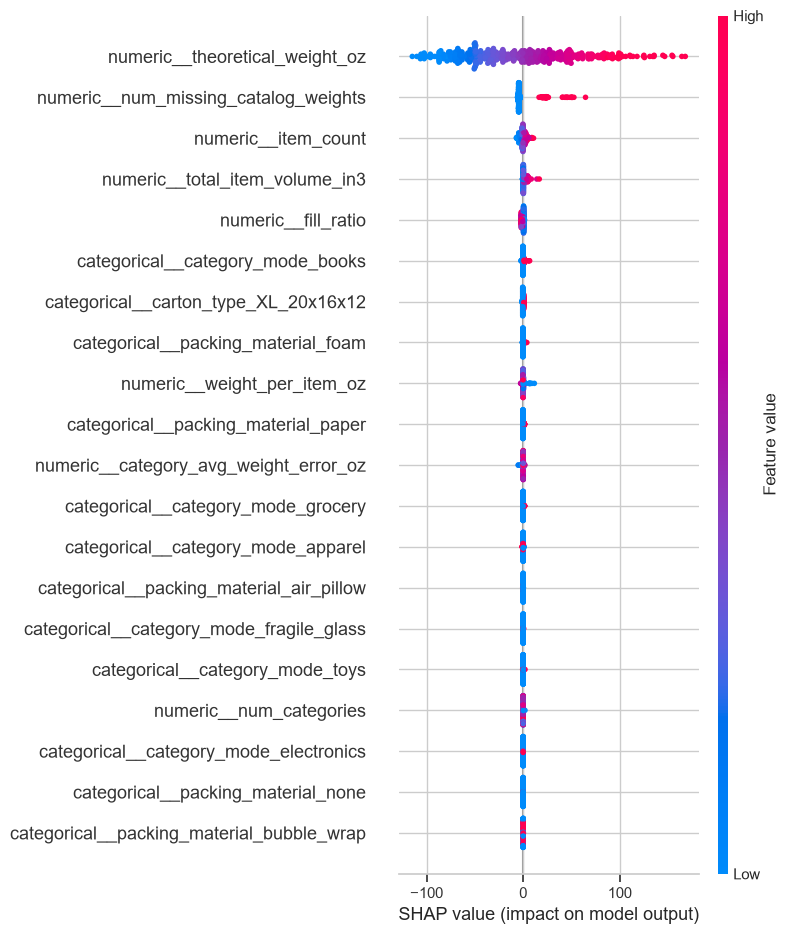

In [12]:
import shap

preprocessor = best_model.named_steps['preprocess']
model = best_model.named_steps['model']
X_test_transformed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed[:500])
shap.summary_plot(shap_values, X_test_transformed[:500], feature_names=feature_names)

**How to read this plot:** each row is one feature, sorted top-to-bottom by
overall importance. Each dot is one shipment; its horizontal position is
that feature's SHAP value for that shipment (right = pushed the prediction
up, left = pushed it down), and its color is the feature's actual value
(red = high, blue = low) for that shipment. So if `theoretical_weight_oz`
sits at the top with red dots on the right and blue dots on the left, that's
the unsurprising, expected signal: higher theoretical weight pushes the
prediction higher. The more informative rows are further down — e.g. if
`num_missing_catalog_weights` or `category_avg_weight_error_oz` show a clear
left-right color split, that's the model demonstrably using those
correction signals rather than just restating `theoretical_weight_oz`. A
tight vertical scatter with no color separation for a feature means the
model isn't getting much signal from it on this dataset.

**Caveat:** this whole notebook runs on synthetic data, so what SHAP shows is
"which features did the model learn to use to recover the noise structure I
programmed into the generator" — not "which features matter for real
shipment weight." Once real data lands, rerunning this section is the fastest
way to check whether the model's reliance on `theoretical_weight_oz` vs. the
correction features looks sane, or whether it's leaning on a feature that
doesn't carry real signal outside this synthetic world.